In [2]:
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

In [4]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

In [5]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


In [6]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


In [7]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

cultivar_names = list(CULTIVARS.keys())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6480, 1530)
y shape: (6480,)


In [9]:
class CNN1D(nn.Module):
    def __init__(self, input_size=1530):
        super(CNN1D, self).__init__()

        # ── Convolutional blocks ──
        self.conv_blocks = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 2
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 3
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 4
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        # Calculate flattened size after conv blocks
        # 1530 → /2 → /2 → /2 → /2 = 1530/16 = 95
        self.flat_size = 128 * (input_size // 16)

        # ── Fully connected layers ──
        self.fc_layers = nn.Sequential(
            nn.Linear(self.flat_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)   # output = single cysteine value
        )

    def forward(self, x):
        # x shape: (batch, 1530)
        x = x.unsqueeze(1)          # → (batch, 1, 1530) for Conv1d
        x = self.conv_blocks(x)     # → (batch, 128, 95)
        x = x.view(x.size(0), -1)  # → flatten: (batch, 12160)
        x = self.fc_layers(x)       # → (batch, 1)
        return x.squeeze(1)         # → (batch,)

# Test the architecture
model_test = CNN1D(input_size=1530)
print(model_test)
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters()):,}")

# Test with dummy input
dummy = torch.randn(4, 1530)
out   = model_test(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  ← should be (4,)")

CNN1D(
  (conv_blocks): Sequential(
    (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): 

In [12]:
def train_cnn(model, X_train, y_train, X_val, y_val,
              epochs=100, batch_size=32, lr=1e-4):

    # Convert to tensors
    X_tr  = torch.FloatTensor(X_train).to(device)
    y_tr  = torch.FloatTensor(y_train).to(device)
    X_v   = torch.FloatTensor(X_val).to(device)
    y_v   = torch.FloatTensor(y_val).to(device)

    # DataLoader for batching
    dataset    = TensorDataset(X_tr, y_tr)
    loader     = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Loss and optimiser
    criterion  = nn.SmoothL1Loss(beta=0.02)   # Huber loss — same as Elham's paper
    optimizer  = optim.AdamW(model.parameters(),
                             lr=lr, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.OneCycleLR(
                     optimizer, max_lr=lr,
                     steps_per_epoch=len(loader),
                     epochs=epochs)

    model.to(device)
    model.train()

    best_val_loss = np.inf
    best_weights  = None
    train_losses  = []
    val_losses    = []

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(loader)
        train_losses.append(avg_train_loss)

        # ── Validation ──
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_v)
            val_loss   = criterion(y_val_pred, y_v).item()
        val_losses.append(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} — "
                  f"Train Loss: {avg_train_loss:.5f}  "
                  f"Val Loss: {val_loss:.5f}")

    # Restore best weights
    model.load_state_dict(best_weights)
    print(f"\nBest validation loss: {best_val_loss:.5f}")

    return model, train_losses, val_losses

Train: (5184, 1530)
Test:  (1296, 1530)

Training CNN — 80/20 Split...
Epoch  10/100 — Train Loss: 0.02552  Val Loss: 0.00793
Epoch  20/100 — Train Loss: 0.02152  Val Loss: 0.00608
Epoch  30/100 — Train Loss: 0.00947  Val Loss: 0.00345
Epoch  40/100 — Train Loss: 0.00327  Val Loss: 0.00258
Epoch  50/100 — Train Loss: 0.00219  Val Loss: 0.00234
Epoch  60/100 — Train Loss: 0.00188  Val Loss: 0.00190
Epoch  70/100 — Train Loss: 0.00151  Val Loss: 0.00177
Epoch  80/100 — Train Loss: 0.00134  Val Loss: 0.00183
Epoch  90/100 — Train Loss: 0.00117  Val Loss: 0.00163
Epoch 100/100 — Train Loss: 0.00115  Val Loss: 0.00162

Best validation loss: 0.00161

=== CNN 80/20 Split Results ===
Train RMSE: 0.0049  R²: 0.9116
Test  RMSE: 0.0081  R²: 0.7571  RPD: 2.0292


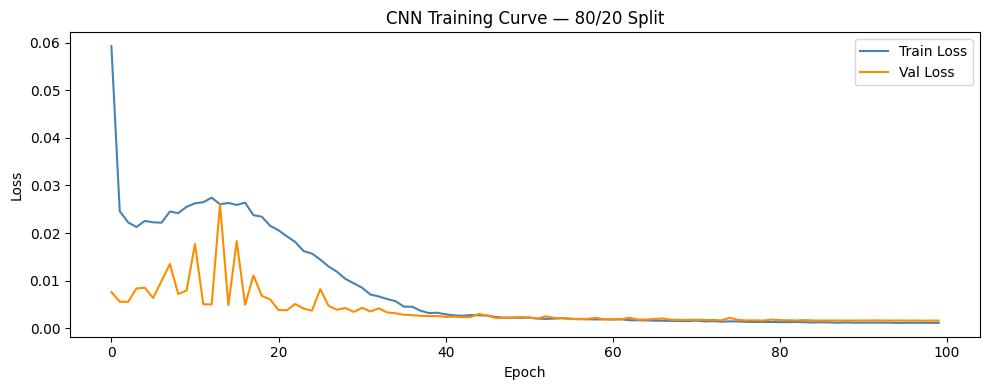

In [13]:
# Apply best preprocessing
X_pre_cnn = snv(savitzky_golay_smooth(X))

# 80/20 split
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_pre_cnn, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train_cnn.shape}")
print(f"Test:  {X_test_cnn.shape}")

# Initialise fresh model
torch.manual_seed(42)
model_8020 = CNN1D(input_size=1530)

# Train
print("\nTraining CNN — 80/20 Split...")
model_8020, train_losses, val_losses = train_cnn(
    model=model_8020,
    X_train=X_train_cnn,
    y_train=y_train_cnn,
    X_val=X_test_cnn,
    y_val=y_test_cnn,
    epochs=100,
    batch_size=32,
    lr=1e-4
)

# Evaluate
model_8020.eval()
with torch.no_grad():
    X_test_t     = torch.FloatTensor(X_test_cnn).to(device)
    X_train_t    = torch.FloatTensor(X_train_cnn).to(device)
    y_pred_test  = model_8020(X_test_t).cpu().numpy()
    y_pred_train = model_8020(X_train_t).cpu().numpy()

rmse_train = np.sqrt(mean_squared_error(y_train_cnn, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test_cnn,  y_pred_test))
r2_train   = r2_score(y_train_cnn, y_pred_train)
r2_test    = r2_score(y_test_cnn,  y_pred_test)
rpd_test   = y_test_cnn.std() / rmse_test

print(f"\n=== CNN 80/20 Split Results ===")
print(f"Train RMSE: {rmse_train:.4f}  R²: {r2_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}  R²: {r2_test:.4f}  RPD: {rpd_test:.4f}")

# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='darkorange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Curve — 80/20 Split")
plt.legend()
plt.tight_layout()
plt.savefig("CNN_training_curve.png", dpi=150)
plt.show()

In [14]:
all_y_true_cnn = []
all_y_pred_cnn = []

for fold_idx, held_out in enumerate(cultivar_names):
    print(f"Fold {fold_idx+1}/20 — Holding out: {CULTIVARS[held_out]['label']}")

    X_tr_l, y_tr_l = [], []
    X_te_l, y_te_l = [], []

    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        for rs, intens in spectra:
            arr     = np.array([intens])
            arr_pre = snv(savitzky_golay_smooth(arr))[0]
            if folder_name == held_out:
                X_te_l.append(arr_pre)
                y_te_l.append(meta['cys'])
            else:
                X_tr_l.append(arr_pre)
                y_tr_l.append(meta['cys'])

    X_tr_l = np.array(X_tr_l)
    y_tr_l = np.array(y_tr_l)
    X_te_l = np.array(X_te_l)
    y_te_l = np.array(y_te_l)

    # Fresh model for each fold
    torch.manual_seed(42)
    model_loco = CNN1D(input_size=1530).to(device)

    # Train
    model_loco, _, _ = train_cnn(
        model=model_loco,
        X_train=X_tr_l,
        y_train=y_tr_l,
        X_val=X_te_l,
        y_val=y_te_l,
        epochs=100,
        batch_size=32,
        lr=1e-4
    )

    # Predict
    model_loco.eval()
    with torch.no_grad():
        X_te_t   = torch.FloatTensor(X_te_l).to(device)
        y_pred_l = model_loco(X_te_t).cpu().numpy()

    fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
    print(f"  RMSE: {fold_rmse:.4f}  "
          f"True: {y_te_l[0]:.4f}  "
          f"Predicted mean: {np.mean(y_pred_l):.4f}\n")

    all_y_true_cnn.extend(y_te_l)
    all_y_pred_cnn.extend(y_pred_l)

all_y_true_cnn = np.array(all_y_true_cnn)
all_y_pred_cnn = np.array(all_y_pred_cnn)

rmse_loco_cnn = np.sqrt(mean_squared_error(all_y_true_cnn, all_y_pred_cnn))
r2_loco_cnn   = r2_score(all_y_true_cnn, all_y_pred_cnn)
rpd_loco_cnn  = all_y_true_cnn.std() / rmse_loco_cnn

print(f"\n=== CNN LOCOCV Results ===")
print(f"Global RMSE: {rmse_loco_cnn:.4f}")
print(f"Global R²:   {r2_loco_cnn:.4f}")
print(f"Global RPD:  {rpd_loco_cnn:.4f}")

Fold 1/20 — Holding out: AAC Chrome
Epoch  10/100 — Train Loss: 0.02502  Val Loss: 0.02815
Epoch  20/100 — Train Loss: 0.01942  Val Loss: 0.00294
Epoch  30/100 — Train Loss: 0.00720  Val Loss: 0.00836
Epoch  40/100 — Train Loss: 0.00233  Val Loss: 0.01630
Epoch  50/100 — Train Loss: 0.00184  Val Loss: 0.01489
Epoch  60/100 — Train Loss: 0.00153  Val Loss: 0.01937
Epoch  70/100 — Train Loss: 0.00135  Val Loss: 0.01692
Epoch  80/100 — Train Loss: 0.00122  Val Loss: 0.01636
Epoch  90/100 — Train Loss: 0.00108  Val Loss: 0.01636
Epoch 100/100 — Train Loss: 0.00104  Val Loss: 0.01577

Best validation loss: 0.00166
  RMSE: 0.0081  True: 0.3172  Predicted mean: 0.3218

Fold 2/20 — Holding out: AAC Lacombe
Epoch  10/100 — Train Loss: 0.02431  Val Loss: 0.00112
Epoch  20/100 — Train Loss: 0.01910  Val Loss: 0.01001
Epoch  30/100 — Train Loss: 0.00821  Val Loss: 0.00297
Epoch  40/100 — Train Loss: 0.00319  Val Loss: 0.00137
Epoch  50/100 — Train Loss: 0.00195  Val Loss: 0.00216
Epoch  60/100 — T